In [2]:
# %load_ext autoreload
# %autoreload 2

import sys
import pathlib

# Ensure the notebook can import the local src package from the project root.
project_root = pathlib.Path.cwd()
if not (project_root / 'src').exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root.resolve()))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sunpy.net import Fido, attrs as a
import astropy.units as u
from astropy.io import fits
import sunpy.map


from src.utilities import make_cube

In [6]:
t_start = '2017-08-07 12:00:00'
t_end   = '2017-08-07 12:10:00'
time_range = a.Time(t_start, t_end)

In [7]:
result_continuum = Fido.search(
    time_range,
    a.Instrument.hmi,
    a.Physobs.intensity,
)
print("=== Continuum ===")
print(result_continuum)

=== Continuum ===
Results from 1 Provider:

13 Results from the VSOClient:
Source: https://sdac.virtualsolar.org/cgi/search
Data retrieval status: http://docs.virtualsolar.org/wiki/VSOHealthReport

       Start Time               End Time        Source Instrument    Wavelength    Provider  Physobs  Wavetype Extent Width Extent Length Extent Type   Size  
                                                                      Angstrom                                                                         Mibyte 
----------------------- ----------------------- ------ ---------- ---------------- -------- --------- -------- ------------ ------------- ----------- --------
2017-08-07 12:00:37.000 2017-08-07 12:00:38.000    SDO        HMI 6173.0 .. 6174.0     JSOC intensity   NARROW         4096          4096    FULLDISK -0.00098
2017-08-07 12:01:22.000 2017-08-07 12:01:23.000    SDO        HMI 6173.0 .. 6174.0     JSOC intensity   NARROW         4096          4096    FULLDISK -0.00098
2017-08

In [ ]:
result_doppler = Fido.search(
    time_range,
    a.Instrument.hmi,
    a.Physobs.los_velocity,
    
)
print("\n=== Doppler ===")
print(result_doppler)


=== Doppler ===
Results from 1 Provider:

13 Results from the VSOClient:
Source: https://sdac.virtualsolar.org/cgi/search
Data retrieval status: http://docs.virtualsolar.org/wiki/VSOHealthReport

       Start Time               End Time        Source Instrument    Wavelength    Provider   Physobs    Wavetype Extent Width Extent Length Extent Type   Size  
                                                                      Angstrom                                                                            Mibyte 
----------------------- ----------------------- ------ ---------- ---------------- -------- ------------ -------- ------------ ------------- ----------- --------
2017-08-07 12:00:37.000 2017-08-07 12:00:38.000    SDO        HMI 6173.0 .. 6174.0     JSOC LOS_velocity   NARROW         4096          4096    FULLDISK -0.00098
2017-08-07 12:01:22.000 2017-08-07 12:01:23.000    SDO        HMI 6173.0 .. 6174.0     JSOC LOS_velocity   NARROW         4096          4096    FULLDISK -0

In [10]:
download_dir = pathlib.Path('../data/raw/2017-08-07')
download_dir.mkdir(parents=True, exist_ok=True)

dry_run = False

if  dry_run:
    print(f"Directory {download_dir} already exists. Skipping download.")
else:
    files_continuum   = Fido.fetch(result_continuum,   path=download_dir)
    files_doppler     = Fido.fetch(result_doppler,     path=download_dir)
#    files_magnetogram = Fido.fetch(result_magnetogram, path=download_dir)

# for now we won't download the AIA data
# files_aia = {}
# for wl, result in results_aia.items():
#     files_aia[wl] = Fido.fetch(result, path=download_dir)

print(f"Download directory: {download_dir.resolve()}")

Files Downloaded:   0%|          | 0/13 [00:00<?, ?file/s]

hmi.ic_45s.2017.08.07_12_03_45_TAI.continuum.fits:   0%|          | 0.00/15.5M [00:00<?, ?B/s]

2026-05-28 14:45:37 - parfive - INFO: http://netdrms01.nispdc.nso.edu/cgi-bin/netdrms/drms_export.cgi?series=hmi__Ic_45s;compress=rice;record=17250242-17250242 failed to download with exception
Download Failed: http://netdrms01.nispdc.nso.edu/cgi-bin/netdrms/drms_export.cgi?series=hmi__Ic_45s;compress=rice;record=17250242-17250242 with error <ClientResponse(http://netdrms01.nispdc.nso.edu/cgi-bin/netdrms/drms_export.cgi?series=hmi__Ic_45s;compress=rice;record=17250242-17250242) [500 Internal Server Error]>
<CIMultiDictProxy('Date': 'Thu, 28 May 2026 19:44:54 GMT', 'Server': 'Apache/2.2.15 (CentOS)', 'Content-Length': '624', 'Connection': 'close', 'Content-Type': 'text/html; charset=iso-8859-1')>

2026-05-28 14:45:37 - parfive - INFO: http://netdrms01.nispdc.nso.edu/cgi-bin/netdrms/drms_export.cgi?series=hmi__Ic_45s;compress=rice;record=17250243-17250243 failed to download with exception
Download Failed: http://netdrms01.nispdc.nso.edu/cgi-bin/netdrms/drms_export.cgi?series=hmi__Ic_45s;

12/0 files failed to download. Please check `.errors` for details


Files Downloaded:   0%|          | 0/13 [00:00<?, ?file/s]

hmi.v_45s.2017.08.07_12_01_30_TAI.Dopplergram.fits:   0%|          | 0.00/17.6M [00:00<?, ?B/s]

2026-05-28 14:46:43 - parfive - INFO: http://netdrms01.nispdc.nso.edu/cgi-bin/netdrms/drms_export.cgi?series=hmi__V_45s;compress=rice;record=17250243-17250243 failed to download with exception
Download Failed: http://netdrms01.nispdc.nso.edu/cgi-bin/netdrms/drms_export.cgi?series=hmi__V_45s;compress=rice;record=17250243-17250243 with error <ClientResponse(http://netdrms01.nispdc.nso.edu/cgi-bin/netdrms/drms_export.cgi?series=hmi__V_45s;compress=rice;record=17250243-17250243) [500 Internal Server Error]>
<CIMultiDictProxy('Date': 'Thu, 28 May 2026 19:45:40 GMT', 'Server': 'Apache/2.2.15 (CentOS)', 'Content-Length': '624', 'Connection': 'close', 'Content-Type': 'text/html; charset=iso-8859-1')>

2026-05-28 14:46:43 - parfive - INFO: http://netdrms01.nispdc.nso.edu/cgi-bin/netdrms/drms_export.cgi?series=hmi__V_45s;compress=rice;record=17250244-17250244 failed to download with exception
Download Failed: http://netdrms01.nispdc.nso.edu/cgi-bin/netdrms/drms_export.cgi?series=hmi__V_45s;compr

12/0 files failed to download. Please check `.errors` for details
Download directory: /home/thomas/Desktop/sun_spots_pulsation_review/data/raw/2017-08-07


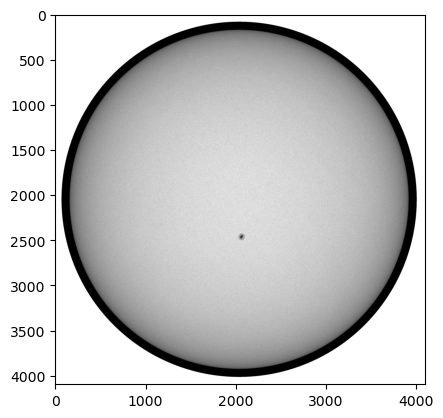

In [13]:
file_list = sorted(download_dir.glob('hmi.*.continuum.fits'))


with fits.open(file_list[0]) as hdu:
    data_shape = hdu[1].data.shape
    header = hdu[1].header.copy()

plt.imshow(hdu[1].data, cmap='gray')
plt.show()

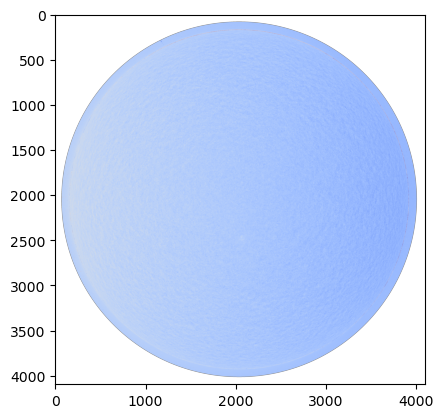

In [17]:
file_list = sorted(download_dir.glob('hmi.v_45s.*.fits'))


with fits.open(file_list[0]) as hdu:
    data_shape = hdu[1].data.shape
    header = hdu[1].header.copy()

plt.imshow(hdu[1].data, cmap='coolwarm')
plt.show()